# CNN Model for Text Classification

This notebook handles the entire pipeline for training a CNN model on text data:
1. Data loading and preprocessing
2. Text tokenization and sequence creation
3. Word embeddings
4. CNN model architecture
5. Model training and evaluation
6. Model saving


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import re
import string
import nltk
from nltk.tokenize import word_tokenize
import keras_tuner as kt
import os

nltk.download('punkt', quiet=True)

np.random.seed(2025)
tf.random.set_seed(2025)


2025-03-27 22:35:31.838766: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-27 22:35:32.017438: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743114932.087650  198101 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743114932.104102  198101 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-27 22:35:32.260464: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Data Preparation

In [ ]:

print("Loading dataset...")
df = pd.read_csv("../datasets/custom_dataset.csv", sep="\t")
print(f"Dataset shape: {df.shape}")
df.head()


Loading dataset...
Dataset shape: (5437, 2)


,Text,Label
0,"In mechanics, a variable-mass system is a coll...",Human
1,Variable-mass systems in fluids involve object...,AI
2,"Geomechanics (from the Greek γεός, i.e. prefix...",Human
3,Geomechanics studies the mechanical behavior o...,AI
4,Microscale chemistry (often referred to as sma...,Human


In [3]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+\.\S+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)

df[['Text', 'cleaned_text']].sample(5)

labels = df['Label'].apply(lambda x: 0 if x == 'Human' else 1).values

print(f"Label distribution: {pd.Series(labels).value_counts().to_dict()}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['cleaned_text'].values, labels, test_size=0.3, random_state=2025, stratify=labels
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=2025, stratify=temp_labels
)

print(f"Training set: {len(train_texts)} samples")
print(f"Validation set: {len(val_texts)} samples")
print(f"Test set: {len(test_texts)} samples")


Label distribution: {1: 3461, 0: 1976}
Training set: 3805 samples
Validation set: 816 samples
Test set: 816 samples


In [4]:
max_words = 2500
max_seq_length = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")

train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=max_seq_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_seq_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_seq_length, padding='post', truncating='post')

print(f"Training sequences shape: {train_padded.shape}")
print(f"Validation sequences shape: {val_padded.shape}")
print(f"Test sequences shape: {test_padded.shape}")


Vocabulary size: 2500
Training sequences shape: (3805, 128)
Validation sequences shape: (816, 128)
Test sequences shape: (816, 128)


## Model Development

In [ ]:
def build_cnn_model(hp):
    embedding_dim = hp.Int('embedding_dim', 64, 256, step=64)
    
    input_layer = layers.Input(shape=(max_seq_length,))
    
    embedding_layer = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_seq_length,
        embeddings_initializer=initializers.GlorotUniform(seed=2025)
    )(input_layer)
    
    filter_sizes = [2, 3, 4, 5]
    conv_layers = []
    
    for filter_size in filter_sizes:
        num_filters = hp.Int(f'num_filters_{filter_size}', 32, 256, step=32)
        conv = layers.Conv1D(
            filters=num_filters,
            kernel_size=filter_size,
            padding='valid',
            activation='relu',
            strides=1
        )(embedding_layer)
        
        pool = layers.GlobalMaxPooling1D()(conv)
        conv_layers.append(pool)
    
    if len(conv_layers) > 1:
        merged = layers.Concatenate()(conv_layers)
    else:
        merged = conv_layers[0]
    
    merged = layers.Dropout(hp.Float('dropout_rate', 0.1, 0.5, step=0.1))(merged)
    
    for i in range(hp.Int('num_dense_layers', 1, 2)):
        merged = layers.Dense(
            units=hp.Int(f'dense_units_{i}', 16, 128, step=16),
            activation='relu'
        )(merged)
        merged = layers.Dropout(hp.Float(f'dense_dropout_{i}', 0.1, 0.5, step=0.1))(merged)
    
    output = layers.Dense(1, activation='sigmoid')(merged)
    
    model = keras.Model(inputs=input_layer, outputs=output)
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(), keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model

tuner = kt.Hyperband(
    build_cnn_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='../tuner_results',
    project_name='cnn_model'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

tuner.search(
    train_padded, train_labels,
    epochs=25,
    validation_data=(val_padded, val_labels),
    callbacks=[early_stopping]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters: {best_hps.values}")


Trial 30 Complete [00h 00m 53s]
val_accuracy: 0.9901960492134094

Best val_accuracy So Far: 0.9950980544090271
Total elapsed time: 00h 12m 03s
Best hyperparameters: {'embedding_dim': 192, 'num_filters_2': 32, 'num_filters_3': 192, 'num_filters_4': 256, 'num_filters_5': 192, 'dropout_rate': 0.30000000000000004, 'num_dense_layers': 2, 'dense_units_0': 128, 'dense_dropout_0': 0.2, 'learning_rate': 0.0003133857760621912, 'dense_units_1': 112, 'dense_dropout_1': 0.1, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}


Epoch 1/30
118/119 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6506 - auc_3: 0.6789 - loss: 0.6111 - precision_3: 0.6605 - recall_3: 0.9413

119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6522 - auc_3: 0.6820 - loss: 0.6088 - precision_3: 0.6616 - recall_3: 0.9419 - val_accuracy: 0.9645 - val_auc_3: 0.9932 - val_loss: 0.1122 - val_precision_3: 0.9521 - val_recall_3: 0.9942 - learning_rate: 3.1339e-04
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9711 - auc_3: 0.9952 - loss: 0.0895 - precision_3: 0.9723 - recall_3: 0.9827

119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9711 - auc_3: 0.9952 - loss: 0.0893 - precision_3: 0.9724 - recall_3: 0.9827 - val_accuracy: 0.9853 - val_auc_3: 0.9993 - val_loss: 0.0408 - val_precision_3: 0.9811 - val_recall_3: 0.9962 - learning_rate: 3.1339e-04
Epoch 3/30
118/119 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9958 - auc_3: 0.9994 - loss: 0.0211 - precision_3: 0.9967 - recall_3: 0.9967

119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9957 - auc_3: 0.9993 - loss: 0.0211 - precision_3: 0.9966 - recall_3: 0.9966 - val_accuracy: 0.9853 - val_auc_3: 0.9998 - val_loss: 0.0364 - val_precision_3: 0.9774 - val_recall_3: 1.0000 - learning_rate: 3.1339e-04
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9983 - auc_3: 0.9999 - loss: 0.0078 - precision_3: 0.9996 - recall_3: 0.9978

119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9983 - auc_3: 0.9999 - loss: 0.0078 - precision_3: 0.9996 - recall_3: 0.9978 - val_accuracy: 0.9902 - val_auc_3: 0.9998 - val_loss: 0.0183 - val_precision_3: 0.9867 - val_recall_3: 0.9981 - learning_rate: 3.1339e-04
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9998 - auc_3: 1.0000 - loss: 0.0030 - precision_3: 0.9999 - recall_3: 0.9997

119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9998 - auc_3: 1.0000 - loss: 0.0030 - precision_3: 0.9999 - recall_3: 0.9997 - val_accuracy: 0.9951 - val_auc_3: 0.9999 - val_loss: 0.0157 - val_precision_3: 0.9943 - val_recall_3: 0.9981 - learning_rate: 3.1339e-04
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9998 - auc_3: 1.0000 - loss: 0.0018 - precision_3: 0.9997 - recall_3: 1.0000

119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9998 - auc_3: 1.0000 - loss: 0.0018 - precision_3: 0.9997 - recall_3: 1.0000 - val_accuracy: 0.9939 - val_auc_3: 0.9999 - val_loss: 0.0131 - val_precision_3: 0.9924 - val_recall_3: 0.9981 - learning_rate: 3.1339e-04
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 1.0000 - auc_3: 1.0000 - loss: 6.6778e-04 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 0.9939 - val_auc_3: 0.9999 - val_loss: 0.0136 - val_precision_3: 0.9942 - val_recall_3: 0.9962 - learning_rate: 3.1339e-04
Epoch 8/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 1.0000 - auc_3: 1.0000 - loss: 4.6985e-04 - precision_3: 1.0000 - recall_3: 1.0000 - val_accuracy: 0.9939 - val_auc_3: 0.9999 - val_loss: 0.0158 - val_precision_3: 0.9924 - val_recall_3: 0.9981 - learning_rate: 3.1339e-04
Epoch 9/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 1.0000 - auc_3: 1.0000 - loss: 2.4452e-04 - precision_3: 1.0000 - recall_3: 1.0000 - val_

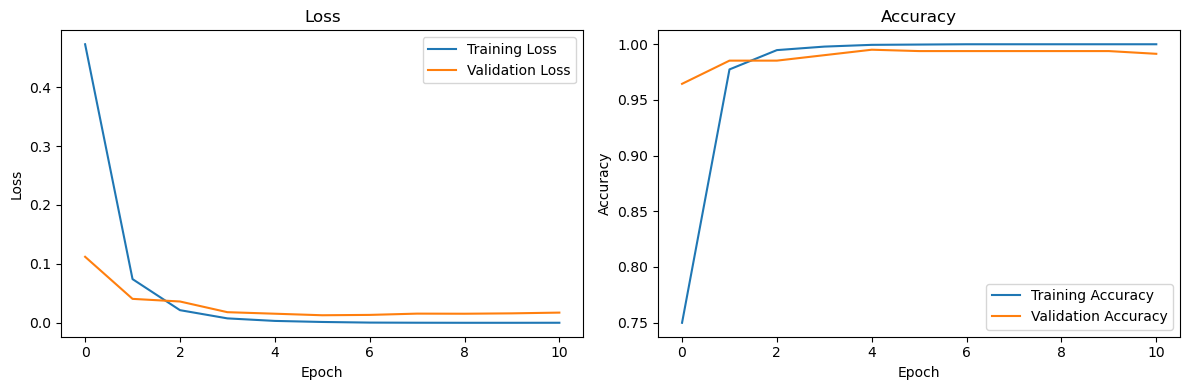

In [ ]:
model = tuner.hypermodel.build(best_hps)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('../trained_models/tensorflow/cnn_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    train_padded, train_labels,
    validation_data=(val_padded, val_labels),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Model Evaluation

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9983 - auc_3: 1.0000 - loss: 0.0099 - precision_3: 0.9973 - recall_3: 1.0000
Test accuracy: 0.9963
Test AUC: 0.9999
Test precision: 0.9943
Test recall: 1.0000
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


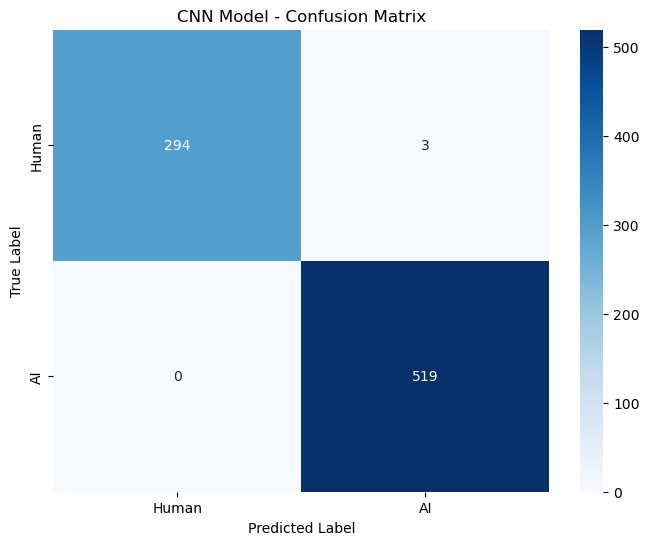

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      0.99      0.99       297
          AI       0.99      1.00      1.00       519

    accuracy                           1.00       816
   macro avg       1.00      0.99      1.00       816
weighted avg       1.00      1.00      1.00       816



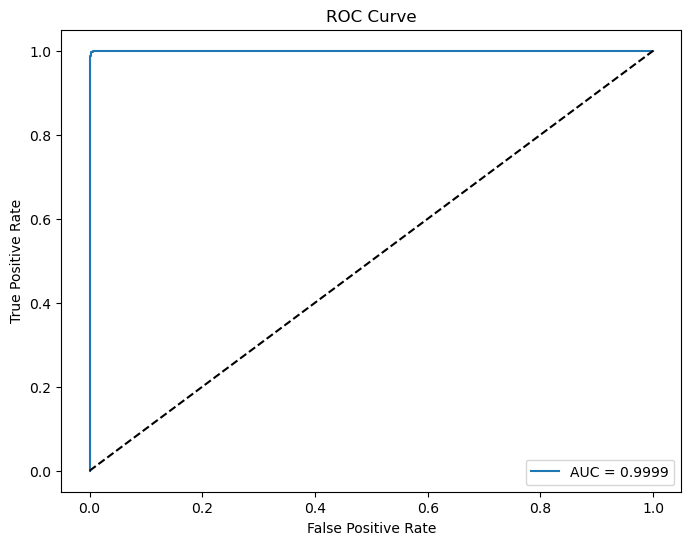

Could not visualize feature importance: list index out of range


In [ ]:
model = keras.models.load_model('../trained_models/tensorflow/cnn_model.h5')

test_loss, test_acc, test_auc, test_precision, test_recall = model.evaluate(test_padded, test_labels)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")

y_pred_prob = model.predict(test_padded)
y_pred = (y_pred_prob > 0.5).astype(int)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_labels, y_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI']
)
plt.title('CNN Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("Classification Report:")
print(classification_report(test_labels, y_pred, target_names=['Human', 'AI']))

fpr, tpr, _ = roc_curve(test_labels, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

try:
    embedding_layer = model.layers[0]
    embedding_weights = embedding_layer.get_weights()[0]
    
    word_norms = np.linalg.norm(embedding_weights, axis=1)
    top_indices = np.argsort(word_norms)[-20:]  # Top 20 words
    
    index_word = {v: k for k, v in tokenizer.word_index.items()}
    top_words = [index_word.get(i+1, '') for i in top_indices if i+1 in index_word]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_words)), word_norms[top_indices][::-1])
    plt.yticks(range(len(top_words)), top_words[::-1])
    plt.title('Words with Highest Embedding Norm')
    plt.xlabel('Norm')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not visualize feature importance: {str(e)}")


## Model Deployment

In [ ]:
model.save('../trained_models/tensorflow/cnn_model.h5')
print("Model saved to '../trained_models/tensorflow/cnn_model.h5'")

import pickle

with open('../trained_models/tensorflow/cnn_tokenizer.pkl', 'wb') as f:
    pickle.dump({
        'tokenizer': tokenizer,
        'max_seq_length': max_seq_length,
        'clean_text': clean_text
    }, f)
print("Tokenizer saved to '../trained_models/tensorflow/cnn_tokenizer.pkl'")

def predict_text(text, model, preprocessor):
    cleaned_text = preprocessor['clean_text'](text)
    
    sequence = preprocessor['tokenizer'].texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
    
    prediction = model.predict(padded)[0][0]
    
    return {
        'probability': float(prediction),
        'prediction': 'AI' if prediction > 0.5 else 'Human'
    }

loaded_model = keras.models.load_model('../trained_models/tensorflow/cnn_model.h5')
with open('../trained_models/tensorflow/cnn_tokenizer.pkl', 'rb') as f:
    loaded_preprocessor = pickle.load(f)

sample_text = "This is a sample text to test the model."
result = predict_text(sample_text, loaded_model, loaded_preprocessor)
print(f"Sample text: '{sample_text}'")
print(f"Prediction: {result['prediction']}")

Model saved to '../../trained_models/tensorflow/cnn_model.h5'
Tokenizer saved to '../../trained_models/tensorflow/cnn_tokenizer.pkl'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Sample text: 'This is a sample text to test the model.'
Prediction: Human (Probability: 0.0017)


## Load dataset

In [ ]:
print("Loading dataset...")
try:
    df = pd.read_csv('../datasets/submission3_inputs.csv', sep=';')
except:
    df = pd.read_csv('../datasets/submission3_inputs.csv')

print(f"Dataset loaded with {len(df)} entries")

df.head()

## Make predictions with CNN Model

In [ ]:

print("Making predictions with CNN model...")
cnn_predictions = []
for idx, row in df.iterrows():
    text = row['Text']
    prediction = predict_text(text, loaded_model, loaded_preprocessor)['prediction']
    cnn_predictions.append(prediction)
    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1}/{len(df)} entries with CNN model")

cnn_results = pd.DataFrame({
    'ID': df['ID'],
    'Label': cnn_predictions
})

cnn_results.head()

## Save Results

In [ ]:

if not os.path.exists('results'):
    os.makedirs('results')

cnn_results.to_csv('results/submissao3-grupo011-s1.csv', sep='\t', index=False)